[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flexfengfeng/dsai-m3-ml-genai/blob/main/L08-computer-vision/notebooks/02_convolutions_intuition.ipynb)

# L08 · NB 02 — Convolutions, by hand

> *Before we let PyTorch learn kernels for us, let's run a few by hand and watch what they do.*

This notebook is fully manual. We will:

1. Pull a Fashion-MNIST image
2. Build three hand-crafted 3×3 kernels (edge detector, blur, sharpen)
3. Convolve each kernel with the image and look at the output feature maps
4. Build a stack of two kernels and see what compositionality looks like
5. Connect the manual operation to `nn.Conv2d`

This is the **why** behind CNNs. By the end you should be able to look at a kernel and predict its feature map.

### The big picture — what is a Convolutional Neural Network (CNN), and why?

A CNN is a neural network built for **images**. Its entire foundation is one operation — **convolution** — repeated and stacked. This notebook teaches you that single operation *by hand* before letting PyTorch automate it.

**The problem CNNs solve:** an image is a huge grid of pixels. If you flatten a 224×224 colour image and feed it to a plain *fully-connected* network, the first layer alone needs ~38 million weights. That is wasteful, and it throws away a key fact: **nearby pixels are related**. A CNN exploits that by sliding a tiny reusable filter over small local neighbourhoods — far fewer parameters, and it respects the spatial structure of the image.

**The roadmap below, and the purpose of each step:**

| Step | What we do | Why it matters |
|------|-----------|----------------|
| §1 | Load one real image | Something concrete to run filters on |
| §2 | Build 3 kernels by hand | A kernel is just 9 numbers; the *pattern* decides what it detects |
| §3 | Convolve from scratch | Demystify convolution: slide → multiply → sum → one output pixel |
| §4 | View the feature maps | *See* that the same 9 numbers produce edges / blur / sharpen |
| §5 | Reproduce with `nn.Conv2d` | PyTorch's layer is exactly our loop — accelerated and **learnable** |
| §6 | Many kernels at once | A real layer learns *many* kernels; **training = learning the kernels** |
| §7 | Max-pooling | Shrink the map → less compute + tolerance to small shifts |
| §8 | The CNN block | `Conv2d → ReLU → MaxPool2d`, stacked, is a working CNN |

Keep this mental model as you go: **a kernel is a pattern detector, and a CNN is a stack of kernels that the network learns from data.**

## 1 · Setup & one image

Selected image: Coat  | shape: (28, 28)


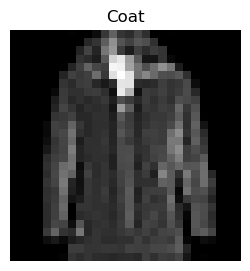

In [2]:
# SETUP: load the tools we need and pick ONE picture to experiment on.
# We grab a single "Coat" photo from the Fashion-MNIST dataset (a famous
# collection of tiny 28x28 grayscale clothing images) so we have something
# real to run our filters on later.

import numpy as np                       # numpy: fast number-crunching on grids of numbers
import matplotlib.pyplot as plt          # matplotlib: draws charts and shows images
import torch                             # torch (PyTorch): the deep-learning library
import torch.nn as nn                    # nn: ready-made neural-network building blocks
import torch.nn.functional as F          # F: function versions of those building blocks
import torchvision.transforms as T       # transforms: turns raw images into numbers
from torchvision.datasets import FashionMNIST  # the clothing-image dataset itself

torch.set_num_threads(1)                 # keep things simple/reproducible: use 1 CPU thread
torch.manual_seed(42)                    # fix the "randomness" so results are the same each run

# Download (once) and load the training images. ToTensor() rescales each pixel
# from 0-255 down to a 0.0-1.0 decimal, which neural networks prefer.
train_ds = FashionMNIST(root='data/fmnist', train=True, download=True, transform=T.ToTensor())
CLASSES = train_ds.classes               # human-readable names like 'Coat', 'Sneaker', etc.

# Search the dataset for the first image whose label is 4 ("Coat"),
# because a coat has clear vertical edges that make our filters easy to see.
idx = next(i for i, (_, y) in enumerate(train_ds) if y == 4)
img_tensor, label = train_ds[idx]        # img_tensor: the image as numbers; label: its class number
img_np = img_tensor.squeeze().numpy()  # (28, 28)   # convert to a plain 28x28 numpy grid

print(f"Selected image: {CLASSES[label]}  | shape: {img_np.shape}")
# Show the picture so we can see what we're working with.
plt.figure(figsize=(3, 3))
plt.imshow(img_np, cmap='gray')          # 'gray' = display as a black-and-white image
plt.title(CLASSES[label])
plt.axis('off')                          # hide the x/y number axes around the image
plt.show()

## 2 · Three hand-crafted kernels

A kernel is just 9 numbers in a 3×3 grid. The numbers determine **what pattern the kernel responds to**.

In [3]:
# Build three "kernels" by hand. A kernel (also called a filter) is just a small
# grid of numbers — here 3x3 = 9 numbers. We slide it over an image to transform it.
# The pattern of numbers decides WHAT the kernel reacts to (edges, smoothing, etc.).

edge = np.array([                        # EDGE detector: spots sudden brightness changes
    [-1, -1, -1],
    [-1,  8, -1],                        # big +8 in the middle, -1 all around it
    [-1, -1, -1],
], dtype=np.float32)

blur = np.ones((3, 3), dtype=np.float32) / 9.0  # box blur
# ^ BLUR: nine equal weights (each 1/9). It averages a pixel with its neighbours,
#   which smooths the image and removes sharp detail.

sharpen = np.array([                     # SHARPEN: boosts a pixel above its neighbours
    [ 0, -1,  0],
    [-1,  5, -1],                        # strong +5 centre, -1 on the four sides
    [ 0, -1,  0],
], dtype=np.float32)

print('Edge kernel:'); print(edge)
print('Blur kernel:'); print(blur)
print('Sharpen kernel:'); print(sharpen)

Edge kernel:
[[-1. -1. -1.]
 [-1.  8. -1.]
 [-1. -1. -1.]]
Blur kernel:
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
Sharpen kernel:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


**Why these work:**

- **Edge** — centre pixel weighted +8, neighbours -1. On a flat region the sum is 0. On an edge (centre different from neighbours), the sum is large. Highlights edges.
- **Blur** — average of the 9 pixels. Smooths out high-frequency variation.
- **Sharpen** — emphasises the centre relative to its top/bottom/left/right neighbours. Increases local contrast.

## 3 · Manual convolution

Let's write convolution from scratch — no library magic. For each output pixel, multiply the kernel element-wise with the corresponding 3×3 patch of the image and sum.

In [4]:
# Do convolution by hand so we can see exactly what it means.
# "Convolution" = slide the small kernel across every position of the image;
# at each spot, multiply the kernel by the patch underneath it and add up the
# 9 results to get ONE output pixel. The grid of all those results is a "feature map".

def conv2d_manual(image, kernel):
    """Naive 2D convolution. Returns an output the same size as input (zero-padded)."""
    h, w = image.shape                   # height & width of the image
    kh, kw = kernel.shape                # height & width of the kernel (3x3 here)
    pad = kh // 2                        # how many border pixels to add (1 for a 3x3 kernel)
    # "Padding" = add a frame of zeros around the image so the kernel can also sit
    # over the edge pixels; this keeps the output the same size as the input.
    padded = np.pad(image, pad, mode='constant', constant_values=0)
    out = np.zeros_like(image, dtype=np.float32)   # empty grid to hold the results
    for i in range(h):                   # step down every row...
        for j in range(w):               # ...and across every column
            patch = padded[i:i+kh, j:j+kw]         # the 3x3 region under the kernel
            out[i, j] = (patch * kernel).sum()     # multiply element-by-element, then sum
    return out

# Apply each hand-made kernel to the coat image to get three feature maps.
edge_map    = conv2d_manual(img_np, edge)
blur_map    = conv2d_manual(img_np, blur)
sharpen_map = conv2d_manual(img_np, sharpen)
print('Output shapes:', edge_map.shape, blur_map.shape, sharpen_map.shape)

Output shapes: (28, 28) (28, 28) (28, 28)


## 4 · Look at the feature maps

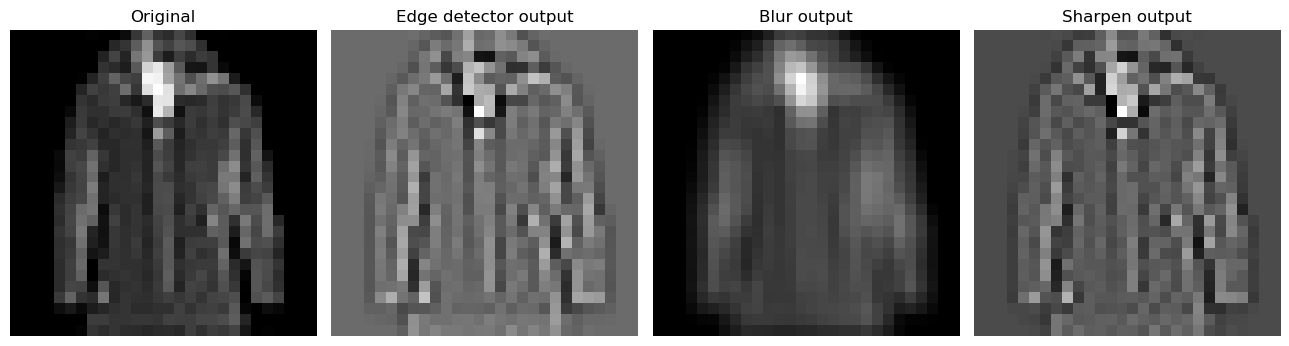

In [5]:
# Show the original image next to its three transformed versions, side by side,
# so we can SEE what each kernel did. subplots(1, 4) makes one row of four pictures.
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
axes[0].imshow(img_np, cmap='gray');    axes[0].set_title('Original')
axes[1].imshow(edge_map, cmap='gray');  axes[1].set_title('Edge detector output')   # edges glow
axes[2].imshow(blur_map, cmap='gray');  axes[2].set_title('Blur output')            # softened
axes[3].imshow(sharpen_map, cmap='gray');axes[3].set_title('Sharpen output')        # crisper
for ax in axes: ax.axis('off')          # hide the number axes on all four panels
plt.tight_layout()                       # neatly space the panels so they don't overlap
plt.show()

See it? The **same 9 numbers** turned a coat photo into "where are the edges?", "smoothed version", and "high-contrast version." That's the whole magic of convolution.

A CNN doesn't hard-code these kernels — it **learns them from data**. But the kernels it learns look a lot like edge detectors in the early layers, and combinations of edges (corners, curves) deeper down.

## 5 · From manual to `nn.Conv2d`

Now let's do the same thing with PyTorch. We'll create a `Conv2d` layer, manually set its weights to our edge kernel, and verify we get the same output.

In [6]:
# Now prove PyTorch's built-in convolution does the SAME thing as our hand-written
# loop. We make a Conv2d layer, force its kernel to be our edge filter, run the
# image through it, and check the result matches our manual edge_map.

# nn.Conv2d expects weights of shape (out_channels, in_channels, kH, kW)
# in_channels=1 (grayscale in), out_channels=1 (one feature map out),
# kernel_size=3 (3x3 filter), padding=1 (keep size), bias=False (no extra add-on number).
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)
with torch.no_grad():                    # no_grad: we're just setting values, not training
    conv.weight.copy_(torch.tensor(edge).view(1, 1, 3, 3))  # load our edge kernel into the layer

# Run the image through it
img_batched = img_tensor.unsqueeze(0)   # (1, 1, 28, 28)
# ^ PyTorch layers expect a "batch" of images, so we add a leading dimension:
#   shape becomes (batch=1, channels=1, height=28, width=28).
with torch.no_grad():
    out = conv(img_batched).squeeze().numpy()   # run it, then drop extra dims back to 28x28

# Compare to our manual result
diff = np.abs(out - edge_map).max()      # biggest difference between the two outputs
print(f"Max absolute difference between manual and nn.Conv2d output: {diff:.6f}")
print(f"They agree to {'machine precision' if diff < 1e-5 else 'wrong'}.")
# A near-zero difference confirms nn.Conv2d is doing exactly our slide-multiply-sum.

Max absolute difference between manual and nn.Conv2d output: 0.000001
They agree to machine precision.


**Same result.** `nn.Conv2d` is just our hand-rolled function, accelerated and learnable.

## 6 · Multiple output channels

A real CNN doesn't learn one kernel — it learns *many*. A single `Conv2d(in_channels=1, out_channels=16, kernel_size=3)` layer learns 16 different 3×3 kernels in parallel, each producing its own feature map.

**First, a word you'll keep seeing: _channel_.**

A **channel** is just **one 2D grid of numbers** (the same height × width as the image). Think of an image not as one flat picture but as a *stack of grids* — each grid is a channel.

- **At the input**, a channel is a colour/brightness map:
  - a **grayscale** image (our coat) = **1 channel** — one 28×28 grid of brightness → `in_channels=1`.
  - a **colour** image = **3 channels** — Red, Green, Blue grids stacked → `in_channels=3`.
- **Inside the network**, a channel = **the output of one kernel** (a feature map). `out_channels=16` means 16 kernels → **16 channels** → e.g. channel 0 = "where are the vertical edges?", channel 1 = "horizontal edges?", and so on.

```
Grayscale input:  1 channel    [ ▢ ]                  28×28
Colour input:     3 channels   [ R ][ G ][ B ]        28×28 each
After conv layer: 16 channels  [ f0 ][ f1 ]…[ f15 ]   28×28 each  ← 16 feature maps
```

Every channel is the same width/height — the channel count is simply **how many grids are stacked**. That's why we write a tensor shape as `(channels, height, width)`: `(16, 28, 28)` = "16 stacked grids, each 28×28."

> In one line: **input channels = what goes in; output channels = how many kernels = how many feature maps come out.**

**Why 16 output channels?**

One kernel detects **one** kind of pattern (edges, or blur, or a texture). But an image contains many useful patterns at once — vertical edges, horizontal edges, diagonals, corners, textures. So we use many kernels in parallel:

- `out_channels=16` means the layer holds **16 separate 3×3 kernels**, each with its own 9 numbers. One image in → **16 feature maps** out. **One channel = one pattern detector = one feature map.**
- **One filter isn't enough.** To tell a "Coat" from a "Sneaker" the network must detect lots of distinct features and combine them. 16 channels = 16 things it can look for at the same time.
- **The network learns what those 16 patterns are.** Here they're random, so the maps look like noise. After training they specialise on their own — some into vertical-edge detectors, some horizontal, some textures. *You don't pick the patterns; training discovers them.*
- **It feeds depth.** This is the "shrink in space, grow in channels" idea (§7–8). Layer 1 learns 16 edge-like filters; layer 2 combines those 16 into 32 higher-level filters (corners, curves); layer 3 into 64 (shapes). The 16 edges are the **building blocks** the next layer assembles into something more complex.

*Analogy:* think of the 16 channels as **16 highlighter pens**, each trained to highlight one kind of structure. The next layer reads all 16 highlights together to spot more complex things.

Why 16 specifically? It's just a design choice (a hyperparameter) — common early-layer values are 16, 32, 64. Bigger = more capacity but more compute.

Layer parameters: 160
Feature maps shape: torch.Size([16, 28, 28])


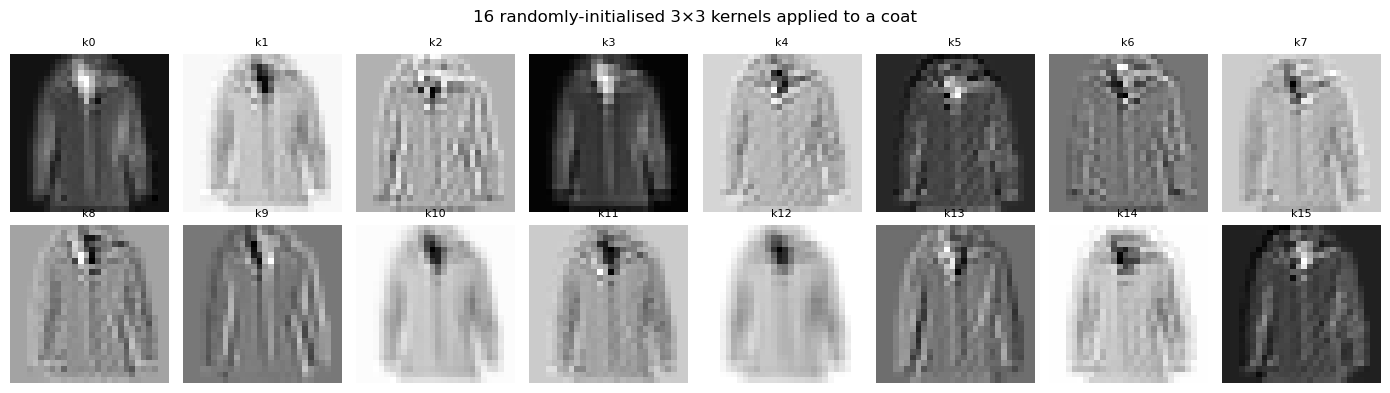

In [7]:
# A real CNN layer learns MANY kernels at once. Here we make one layer that holds
# 16 different 3x3 kernels (out_channels=16), so feeding in our one coat image
# produces 16 feature maps — one per kernel. We leave the kernels at their random
# starting values to show what an UNtrained layer "sees".
multi_conv = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
# Default initialisation = random weights (this is what training would learn)
with torch.no_grad():                    # just running it, not training
    feature_maps = multi_conv(img_batched).squeeze(0)  # (16, 28, 28)  # 16 maps, each 28x28

# Count the learnable numbers in this layer (16 kernels x 9 weights + 16 biases).
print(f"Layer parameters: {sum(p.numel() for p in multi_conv.parameters()):,}")
print(f"Feature maps shape: {feature_maps.shape}")

# Draw all 16 feature maps in a 2-row x 8-column grid so we can eyeball them.
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):       # axes.flat lets us loop over all 16 panels in order
    ax.imshow(feature_maps[i].numpy(), cmap='gray')
    ax.set_title(f'k{i}', fontsize=8)    # label each one k0, k1, ... (k = kernel)
    ax.axis('off')
plt.suptitle('16 randomly-initialised 3×3 kernels applied to a coat')
plt.tight_layout()
plt.show()

These look random because the kernels are random. After training on Fashion-MNIST, these would specialise — some would detect horizontal edges, some vertical, some textures, some specific shapes. **Training = learning the kernels.**

## 7 · Pooling — shrinking the feature map

After a conv layer, we usually downsample. **Max pooling** with a 2×2 window halves the height and width, keeping only the strongest activation in each block. This gives two benefits:

1. Smaller feature maps → less compute, fewer parameters in the next layer
2. **Translation tolerance** — small shifts in the input don't change the pooled output

Before pool: torch.Size([16, 28, 28])
After  pool: torch.Size([16, 14, 14])


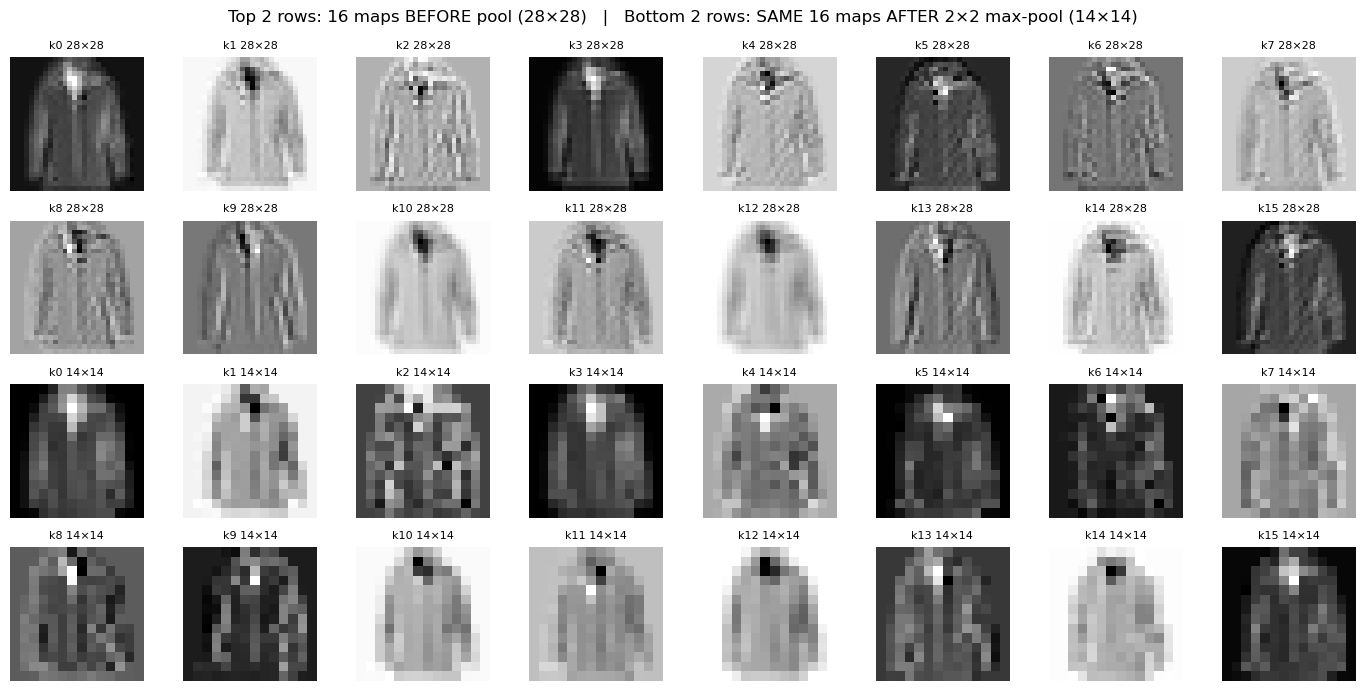

In [8]:
# MAX POOLING: shrink each feature map by keeping only the strongest value in
# every little 2x2 block. This halves the width and height (28 -> 14), cuts the
# amount of data, and makes the result less sensitive to tiny shifts in the input.
# IMPORTANT: pooling is applied to EACH of the 16 channels independently — the
# number of channels stays 16, only the height/width shrink.
pool = nn.MaxPool2d(kernel_size=2)       # 2x2 window, taking the max of each block
with torch.no_grad():
    pooled = pool(feature_maps.unsqueeze(0)).squeeze(0)  # add/remove batch dim around pooling
print(f"Before pool: {feature_maps.shape}")  # (16, 28, 28)
print(f"After  pool: {pooled.shape}")         # (16, 14, 14) — 16 unchanged, 28->14

# Show ALL 16 feature maps before pooling, then ALL 16 after pooling, so it's
# clear that every channel is downsampled on its own (not just one of them).
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i in range(16):
    # top two rows: the 16 maps BEFORE pooling (28x28)
    ax_before = axes[(i // 8), (i % 8)]
    ax_before.imshow(feature_maps[i].numpy(), cmap='gray')
    ax_before.set_title(f'k{i} 28×28', fontsize=8)
    ax_before.axis('off')
    # bottom two rows: the SAME 16 maps AFTER pooling (14x14)
    ax_after = axes[2 + (i // 8), (i % 8)]
    ax_after.imshow(pooled[i].numpy(), cmap='gray')
    ax_after.set_title(f'k{i} 14×14', fontsize=8)
    ax_after.axis('off')
plt.suptitle('Top 2 rows: 16 maps BEFORE pool (28×28)   |   Bottom 2 rows: SAME 16 maps AFTER 2×2 max-pool (14×14)')
plt.tight_layout()
plt.show()

Half the resolution, same essential information. Repeat a few times and you go from `28×28` down to `7×7` while the number of feature channels grows — `1 → 16 → 32 → 64`. The pattern is **shrink in space, grow in channels**.

## 8 · The CNN block — recap

The standard block we'll use in NB 03 is just three operations:

```
Conv2d  →  ReLU  →  MaxPool2d
```

That's the entire pattern. Stack 2–3 of these blocks to extract features, then add a **classifier head** on top to turn those features into an actual answer.

We've now built the feature-extraction half by hand. Next, let's see how that head produces the final prediction.

## 9 · The last step — from feature maps to a prediction

So far we have **features**: stacks of feature maps saying *where* edges, textures, and shapes are. But we still haven't answered the real question — **"what is in this image?"** That's the job of the **head**, and it's just three small steps:

1. **Flatten** — take the final stack of feature maps (e.g. `16 × 14 × 14`) and unroll it into one long list of numbers (16·14·14 = 3136 values). We go from a *spatial grid* to a *plain feature vector*.
2. **Linear (fully-connected) layer** — multiply that vector by learned weights to produce **one score per class** (10 scores for Fashion-MNIST: T-shirt, Trouser, …, Coat, … Ankle boot). Each score = "how much do these features look like class *k*?"
3. **Pick the winner** — `softmax` turns the 10 raw scores into probabilities that sum to 1, and `argmax` picks the highest → the predicted class.

That's the whole journey: **pixels → conv/pool features → flatten → class scores → prediction.** Let's run it on our coat's feature maps.

In [11]:
# Turn the pooled feature maps from section 7 into an actual class prediction.
# We reuse `pooled` (shape 16 x 14 x 14) — the features from our 16 random kernels.

# STEP 1: Flatten the 3D stack of feature maps into one long 1D vector.
flat = pooled.reshape(1, -1)             # (1, 16*14*14) = (1, 3136)
print(f"Feature maps {tuple(pooled.shape)} -> flattened vector {tuple(flat.shape)}")

# STEP 2: A Linear layer maps those 3136 features down to 10 class scores
# (one per Fashion-MNIST class). These weights are random here — a real CNN
# would LEARN them during training so the scores become meaningful.
classifier = nn.Linear(flat.shape[1], 10)   # 3136 inputs -> 10 outputs (10 classes)
with torch.no_grad():
    scores = classifier(flat)            # raw scores, called "logits", shape (1, 10)

# STEP 3: softmax turns the 10 raw scores into probabilities (they sum to 1),
# and argmax picks the index of the largest -> the predicted class.
probs = F.softmax(scores, dim=1).squeeze()
pred = int(probs.argmax())

print("\nClass scores (probabilities):")
for i, name in enumerate(CLASSES):
    marker = "  <-- predicted" if i == pred else ""
    print(f"  {name:12s}: {probs[i]:.3f}{marker}")

print(f"\nPredicted: {CLASSES[pred]}   |   True label: {CLASSES[label]}")
print("(The prediction is basically random — the kernels and classifier are UNTRAINED.")
print(" Training is what makes these numbers correct. That's exactly what NB 03 does.)")

Feature maps (16, 14, 14) -> flattened vector (1, 3136)

Class scores (probabilities):
  T-shirt/top : 0.124  <-- predicted
  Trouser     : 0.108
  Pullover    : 0.111
  Dress       : 0.090
  Coat        : 0.117
  Sandal      : 0.096
  Shirt       : 0.082
  Sneaker     : 0.111
  Bag         : 0.071
  Ankle boot  : 0.091

Predicted: T-shirt/top   |   True label: Coat
(The prediction is basically random — the kernels and classifier are UNTRAINED.
 Training is what makes these numbers correct. That's exactly what NB 03 does.)


### The one takeaway

> Early CNN layers learn **edge detectors**. Deeper layers combine those edges into **corners, curves, and shapes**, and deeper still into whole objects.

This **compositional** structure — simple parts assembled into complex ones — is what makes deep CNNs work, and it is exactly what set off the deep-learning revolution in computer vision around 2012.

And the mechanism behind all of it is the single operation you just ran by hand: **slide a small grid of numbers over the image, multiply, and sum.** Everything else — many kernels, ReLU, pooling, stacking — is built on top of that one idea.

### How many layers does a CNN use?

There's no fixed number — it depends on the problem:

- **Small / teaching models** (like Fashion-MNIST in NB 03): **2–3 conv blocks** are plenty.
- **Classic real-world networks**: AlexNet (2012) ≈ 8 layers, VGG ≈ 16–19, ResNet ≈ 50–152.
- **Rule of thumb**: harder images and more classes → deeper networks. More depth = more levels of feature composition, but also more compute and more data needed to train.

What matters is the *pattern*, not the exact count: each block detects features and combines the previous block's features into something more abstract. Here's the typical job of each stage in a small CNN:

| Stage | Layer(s) | What it detects | Spatial size | Channels |
|-------|----------|-----------------|--------------|----------|
| Input | — | raw pixels | 28×28 | 1 |
| Block 1 | Conv → ReLU → Pool | **edges** (lines at various angles) | 28→14 | 1 → 16 |
| Block 2 | Conv → ReLU → Pool | **corners & curves** (combinations of edges) | 14→7 | 16 → 32 |
| Block 3 | Conv → ReLU → Pool | **textures & object parts** (e.g. a sleeve, a sole) | 7→3 | 32 → 64 |
| Head | Flatten → Linear | **whole-object decision** (Coat? Sneaker?) | — | → 10 classes |

Read it top to bottom: **shrink in space, grow in channels** — the image gets smaller but the description of *what's in it* gets richer, until the final linear layer turns those features into a class prediction.

**What's the "head"?** A CNN has two parts: the **body** (the conv blocks above) that *extracts features* — turning pixels into "there's an edge here, a texture there" — and the **head**, the final `Flatten → Linear` layer(s) that take those features and *make the decision* (which of the 10 classes?). Body = the eyes that report what they see; head = the brain that says "these features → a Coat." (In transfer learning, later in the course, you keep a pre-trained body and just swap in a new head for your own task.)

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## E1 · What happens if you remove padding?

Without padding, a 3×3 kernel shrinks the output by 2 pixels in each dimension. Run two convs in a row and you lose 4. That's why we set `padding=1` for 3×3 kernels — it keeps the output size identical.

In [9]:
# What if we DON'T pad? With padding=0 the kernel can't reach the outer edge,
# so a 3x3 kernel chops 1 pixel off each side: the 28x28 image comes out 26x26.
# This is why we normally use padding=1 with 3x3 kernels — to keep the size unchanged.
no_pad = nn.Conv2d(1, 1, kernel_size=3, padding=0)   # padding=0 means no zero-frame added
with torch.no_grad():
    out = no_pad(img_batched)
print(f"Input shape : {img_batched.shape}")
print(f"Output (no padding): {out.shape}  # 28 - 2 = 26")

Input shape : torch.Size([1, 1, 28, 28])
Output (no padding): torch.Size([1, 1, 26, 26])  # 28 - 2 = 26


## E2 · Try a different kernel: vertical edge detector

The Sobel vertical-edge kernel responds to changes from left → right brightness:

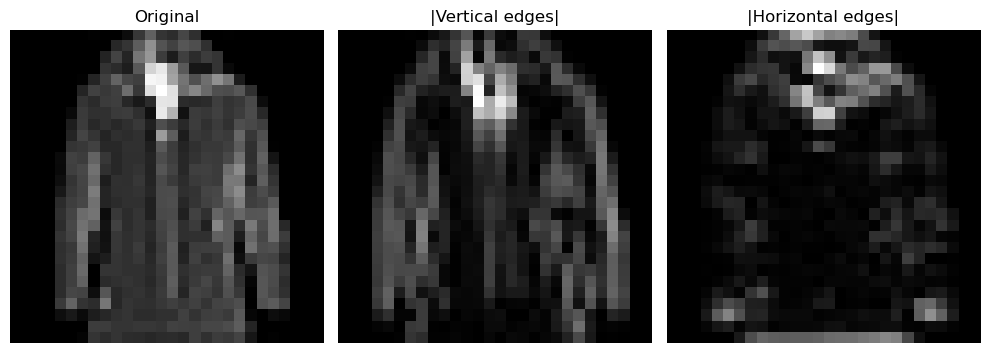

In [10]:
# Try a famous edge kernel called "Sobel". This version reacts to left-to-right
# brightness changes, so it lights up VERTICAL edges. Flipping it (transpose .T)
# turns it into a HORIZONTAL edge detector.
sobel_v = np.array([
    [-1, 0, 1],
    [-2, 0, 2],                          # negative on the left, positive on the right
    [-1, 0, 1],
], dtype=np.float32)

sobel_h = sobel_v.T  # horizontal edges  # .T = transpose (flip rows<->columns)

# Run both kernels through our hand-written convolution from earlier.
vmap = conv2d_manual(img_np, sobel_v)
hmap = conv2d_manual(img_np, sobel_h)

# Show original, vertical edges, horizontal edges. We take abs() because edge
# strength can be negative or positive, and we only care about how strong it is.
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(img_np, cmap='gray');           axes[0].set_title('Original')
axes[1].imshow(np.abs(vmap), cmap='gray');     axes[1].set_title('|Vertical edges|')
axes[2].imshow(np.abs(hmap), cmap='gray');     axes[2].set_title('|Horizontal edges|')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

Different kernel, different feature map. A CNN's first layer typically learns a bank of edge detectors at various angles. Subsequent layers combine these into corners and shapes.

This compositional structure is what makes deep CNNs work — and what motivated the entire deep-learning revolution in computer vision around 2012.